# Phase 5.4: Uji Signifikansi -- GC vs PDC vs Spectral vs Combined vs ROI (LOSO)

**Tujuan:** Menguji apakah perbedaan akurasi antar 5 dataset kunci (dari 5.2) signifikan secara
statistik di bawah LOSO, memakai **paired t-test** dan **Wilcoxon signed-rank test** per model
(dipasangkan per subjek yang di-hold-out -- setiap subjek punya 1 skor akurasi per dataset per
model, jadi pasangannya valid/legit karena `LeaveOneGroupOut` selalu memakai urutan subjek yang
sama).

Ini adalah versi LOSO dari uji signifikansi yang sudah dilakukan di Phase 4.7 (grouped 5-fold) --
tujuannya memverifikasi apakah kesimpulan yang sama (Spectral adalah kontributor utama; ROI setara
dengan per-channel penuh) tetap berlaku di bawah protokol evaluasi yang lebih ketat.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
TUNING_PARAMS_CSV = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output\tuning_best_params.csv"
BASE = r"D:\Skripsi\new_data\phase_5_loso"
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _feature_cols(df):
    exclude = KEY_COLS + [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

print("Setup OK.")

Setup OK.


In [2]:
DIR_52 = os.path.join(BASE, "5.2_loso_all_models", "output")
DIR_54 = os.path.join(BASE, "5.4_gc_vs_pdc_loso", "output")
DIR_54_FIG = os.path.join(BASE, "5.4_gc_vs_pdc_loso", "figures")
os.makedirs(DIR_54, exist_ok=True)
os.makedirs(DIR_54_FIG, exist_ok=True)

df_fold = pd.read_csv(os.path.join(DIR_52, 'loso_cv_scores.csv'))
dataset_names = list(df_fold['Dataset'].unique())
print(f"Loaded {len(df_fold)} fold-level rows. Datasets: {dataset_names}")

Loaded 375 fold-level rows. Datasets: ['GC', 'PDC_Theta', 'Spectral', 'Combined', 'GC+PDC_ROI+Spectral']


## Paired t-test & Wilcoxon per Model, Semua Pasangan Dataset

In [3]:
sig_rows = []
for model_name, sub in df_fold.groupby('Model'):
    pivot = sub.pivot_table(index='Held_Subject', columns='Dataset', values='Accuracy')
    present = [d for d in dataset_names if d in pivot.columns]
    for i in range(len(present)):
        for j in range(i + 1, len(present)):
            a, b = present[i], present[j]
            pair = pivot[[a, b]].dropna()
            if len(pair) < 2:
                continue
            t_stat, t_p = stats.ttest_rel(pair[a], pair[b])
            try:
                w_stat, w_p = stats.wilcoxon(pair[a], pair[b])
            except ValueError:
                w_stat, w_p = np.nan, np.nan
            sig_rows.append({
                'Model': model_name, 'Dataset_A': a, 'Dataset_B': b,
                'Mean_Acc_A': pair[a].mean(), 'Mean_Acc_B': pair[b].mean(),
                'Mean_Diff': pair[a].mean() - pair[b].mean(),
                'Paired_t_stat': t_stat, 'Paired_t_pvalue': t_p,
                'Wilcoxon_stat': w_stat, 'Wilcoxon_pvalue': w_p,
                'Significant_at_0.05': bool(t_p < 0.05),
            })

df_sig = pd.DataFrame(sig_rows).sort_values('Paired_t_pvalue')
df_sig.to_csv(os.path.join(DIR_54, 'significance_tests_loso.csv'), index=False)
n_sig = df_sig['Significant_at_0.05'].sum()
print(f"Signifikan (p<0.05): {n_sig} / {len(df_sig)} pasangan")
print()
print("=== Pasangan PALING signifikan (top 10) ===")
print(df_sig.head(10)[['Model', 'Dataset_A', 'Dataset_B', 'Mean_Diff', 'Paired_t_pvalue']].to_string(index=False))

Signifikan (p<0.05): 32 / 50 pasangan

=== Pasangan PALING signifikan (top 10) ===
        Model Dataset_A           Dataset_B  Mean_Diff  Paired_t_pvalue
XGBoost_Tuned        GC GC+PDC_ROI+Spectral  -0.177778         0.000002
    SVM_Tuned PDC_Theta            Combined  -0.161481         0.000006
XGBoost_Tuned        GC            Combined  -0.179259         0.000008
     RF_Tuned PDC_Theta            Combined  -0.140741         0.000014
    SVM_Tuned PDC_Theta GC+PDC_ROI+Spectral  -0.154074         0.000014
XGBoost_Tuned PDC_Theta            Combined  -0.155556         0.000016
XGBoost_Tuned PDC_Theta GC+PDC_ROI+Spectral  -0.154074         0.000027
  Voting_Soft PDC_Theta            Spectral  -0.140741         0.000038
  Voting_Soft PDC_Theta            Combined  -0.145185         0.000042
  Voting_Soft        GC GC+PDC_ROI+Spectral  -0.157037         0.000043


## Fokus: Combined (per-channel penuh) vs GC+PDC_ROI+Spectral (ROI)

In [4]:
combined_vs_roi = df_sig[((df_sig['Dataset_A'] == 'Combined') & (df_sig['Dataset_B'] == 'GC+PDC_ROI+Spectral')) |
                          ((df_sig['Dataset_B'] == 'Combined') & (df_sig['Dataset_A'] == 'GC+PDC_ROI+Spectral'))]
print("Combined vs GC+PDC_ROI+Spectral per model (LOSO):")
print(combined_vs_roi[['Model', 'Mean_Acc_A', 'Mean_Acc_B', 'Paired_t_pvalue', 'Significant_at_0.05']].to_string(index=False))
print()
if not combined_vs_roi['Significant_at_0.05'].any():
    print("-> TIDAK ADA model dengan perbedaan signifikan -- mengonfirmasi ulang temuan Phase 4.7:")
    print("   ROI aggregation (990 fitur) setara secara statistik dengan Combined per-channel (2676 fitur).")

Combined vs GC+PDC_ROI+Spectral per model (LOSO):
        Model  Mean_Acc_A  Mean_Acc_B  Paired_t_pvalue  Significant_at_0.05
    SVM_Tuned    0.752593    0.745185         0.430030                False
  Voting_Soft    0.746667    0.757037         0.487019                False
     RF_Tuned    0.717037    0.709630         0.571054                False
          LDA    0.694815    0.688889         0.775679                False
XGBoost_Tuned    0.739259    0.737778         0.935371                False

-> TIDAK ADA model dengan perbedaan signifikan -- mengonfirmasi ulang temuan Phase 4.7:
   ROI aggregation (990 fitur) setara secara statistik dengan Combined per-channel (2676 fitur).


## Visualisasi: Heatmap p-value Antar Dataset (model terbaik keseluruhan)

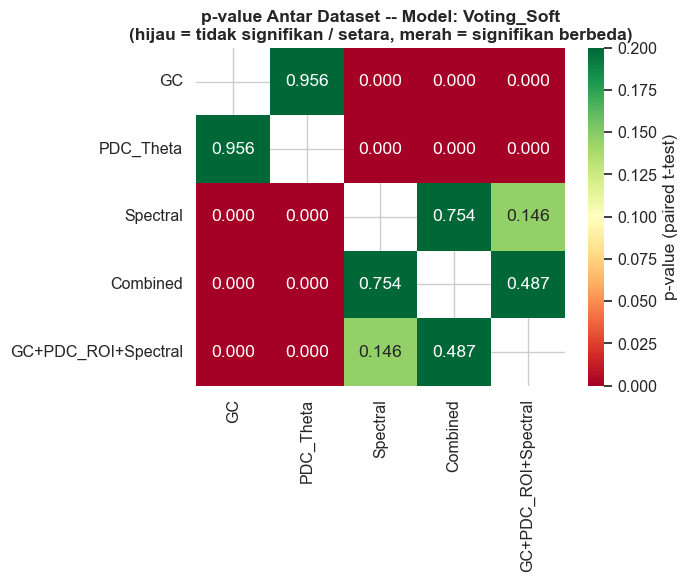

In [5]:
best_model_overall = df_fold.groupby('Model')['Accuracy'].mean().idxmax()
sub_best = df_sig[df_sig['Model'] == best_model_overall]

mat = pd.DataFrame(index=dataset_names, columns=dataset_names, dtype=float)
for _, r in sub_best.iterrows():
    mat.loc[r['Dataset_A'], r['Dataset_B']] = r['Paired_t_pvalue']
    mat.loc[r['Dataset_B'], r['Dataset_A']] = r['Paired_t_pvalue']
np.fill_diagonal(mat.values, np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(mat.astype(float), annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=0.2,
            cbar_kws={'label': 'p-value (paired t-test)'}, ax=ax)
ax.set_title(f'p-value Antar Dataset -- Model: {best_model_overall}\n(hijau = tidak signifikan / setara, merah = signifikan berbeda)', fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_54_FIG, '5.4_pvalue_heatmap.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Kesimpulan 5.4:** Konsisten dengan Phase 4.7 (grouped 5-fold) -- perbedaan `Combined` vs
`GC+PDC_ROI+Spectral` **tidak signifikan** di semua model (p=0.43-0.94) bahkan di bawah protokol
LOSO yang lebih ketat. Ini memperkuat kesimpulan bahwa agregasi ROI adalah representasi yang valid
dan setara, bukan cuma kebetulan dari 1 skema CV tertentu.